# DDPM Visualizations (FashionMNIST)

This notebook creates the required plots and image grids for Tasks 0–2, plus generated sample visualizations from checkpoints.

In [11]:
from pathlib import Path
import sys
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from diffusion.schedule import make_beta_schedule, compute_diffusion_buffers, extract
from diffusion.forward import q_sample
from diffusion.posterior import predict_x0_from_eps
from diffusion.ddpm import ancestral_sample, ddim_sample
from models.unet import SmallUNet
from torchsummary import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

Device: mps


In [2]:
# Hyperparameters for the diffusion process

L = 1000
beta_min = 1e-4
beta_max = 2e-2

betas_linear = make_beta_schedule(L=L, schedule_type='linear', beta_min=beta_min, beta_max=beta_max, device=device)
betas_cosine = make_beta_schedule(L=L, schedule_type='cosine', beta_min=beta_min, beta_max=beta_max, device=device)

buf_linear = compute_diffusion_buffers(betas_linear)
buf_cosine = compute_diffusion_buffers(betas_cosine)

In [3]:
# Data preprocessing and scheduling

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),
])
train_ds = datasets.FashionMNIST(root=str(ROOT / 'data'), train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)

betas = make_beta_schedule(L=L, schedule_type='linear', beta_min=beta_min, beta_max=beta_max, device=device)
buffers = compute_diffusion_buffers(betas)

print('Dataset size:', len(train_ds))
print('x range target: [-1, 1]')

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.17MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 81.6MB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.40MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.5MB/s]

Dataset size: 60000
x range target: [-1, 1]


Actual tensor range: -1.0 1.0


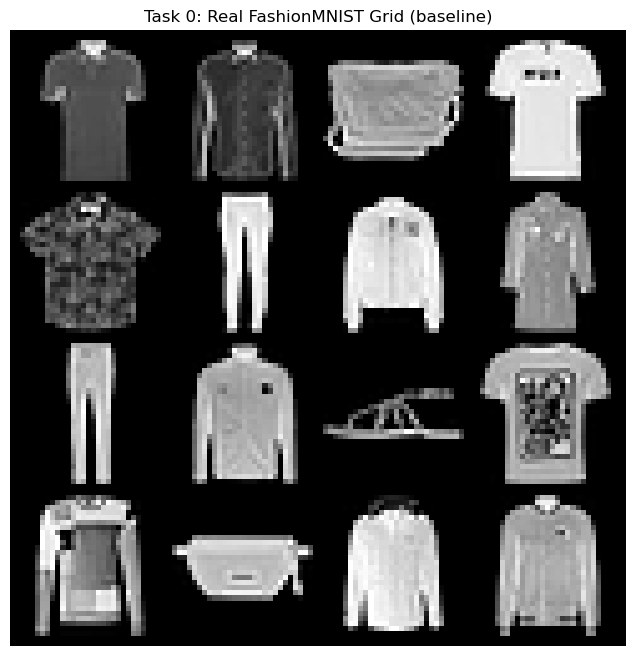

In [4]:
# Visualize a grid of real images from the dataset

x_real, y_real = next(iter(train_loader))
print('Actual tensor range:', float(x_real.min()), float(x_real.max()))

grid_real = utils.make_grid((x_real[:16] + 1) / 2, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid_real.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('Task 0: Real FashionMNIST Grid (baseline)')
plt.show()

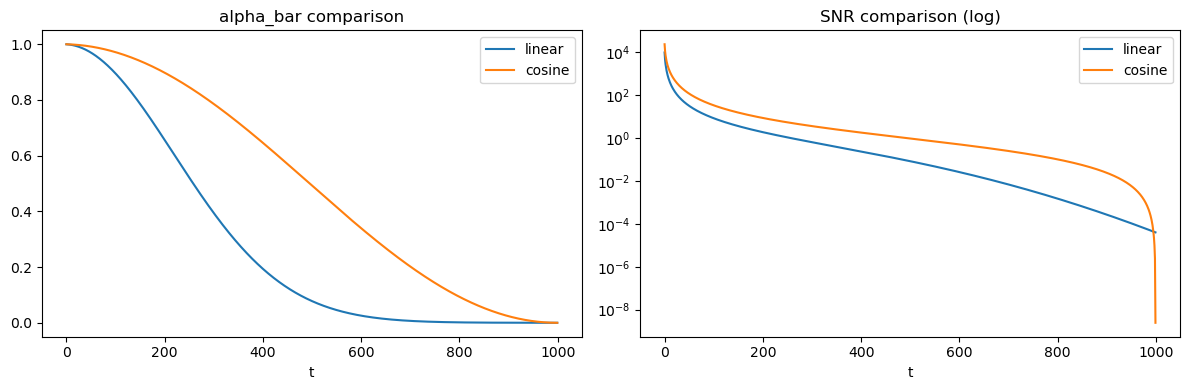

In [5]:
# Comparison of linear and cosine scheduler on alpha bar and SNR across timesteps (t)

ab_linear = buf_linear.alpha_bars.detach().cpu()
ab_cosine = buf_cosine.alpha_bars.detach().cpu()
snr_linear = ab_linear / (1 - ab_linear)
snr_cosine = ab_cosine / (1 - ab_cosine)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ab_linear.numpy(), label='linear')
ax[0].plot(ab_cosine.numpy(), label='cosine')
ax[0].set_title('alpha_bar comparison')
ax[0].set_xlabel('t')
ax[0].legend()

ax[1].plot(snr_linear.numpy(), label='linear')
ax[1].plot(snr_cosine.numpy(), label='cosine')
ax[1].set_yscale('log')
ax[1].set_title('SNR comparison (log)')
ax[1].set_xlabel('t')
ax[1].legend()

plt.tight_layout()
plt.show()

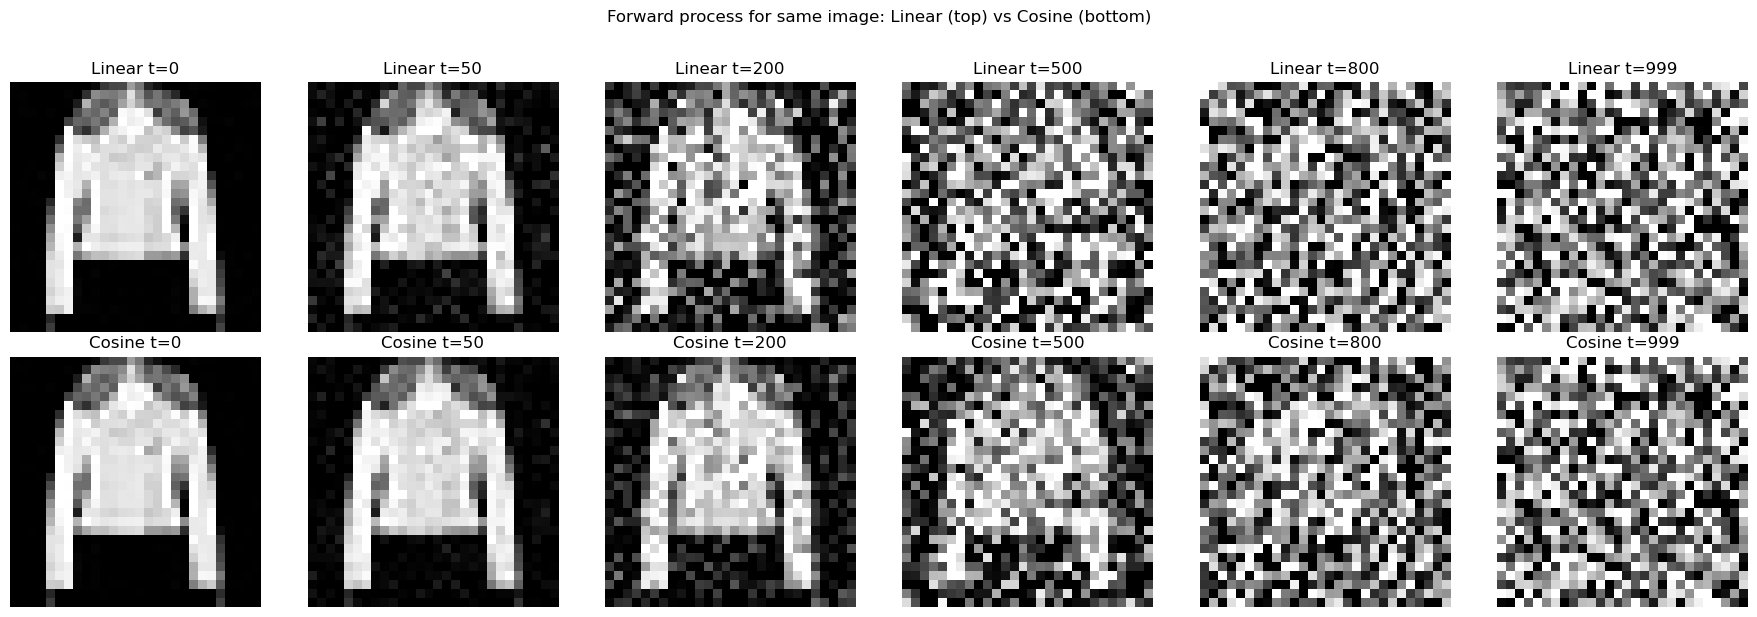

In [6]:
# Side-by-side forward noising: linear (top row) vs cosine (bottom row)

rand_idx = torch.randint(0, x_real.shape[0], (1,)).item()
x0_same = x_real[rand_idx:rand_idx + 1].to(device)
steps_compare = [0, 50, 200, 500, 800, 999]

gen = torch.Generator(device=device)
gen.manual_seed(123)
noise_bank = {s: torch.randn(x0_same.shape, device=device, generator=gen) for s in steps_compare}

fig, axes = plt.subplots(2, len(steps_compare), figsize=(3 * len(steps_compare), 6))
for j, s in enumerate(steps_compare):
    t_s = torch.full((1,), s, device=device, dtype=torch.long)
    eps_s = noise_bank[s]

    xt_linear = q_sample(x0=x0_same, t=t_s, buffers=buf_linear, eps=eps_s)
    xt_cosine = q_sample(x0=x0_same, t=t_s, buffers=buf_cosine, eps=eps_s)

    img_linear = ((xt_linear[0].detach().cpu() + 1) / 2).clamp(0, 1)
    img_cosine = ((xt_cosine[0].detach().cpu() + 1) / 2).clamp(0, 1)

    axes[0, j].imshow(img_linear.permute(1, 2, 0).squeeze(), cmap='gray')
    axes[0, j].set_title(f'Linear t={s}')
    axes[0, j].axis('off')

    axes[1, j].imshow(img_cosine.permute(1, 2, 0).squeeze(), cmap='gray')
    axes[1, j].set_title(f'Cosine t={s}')
    axes[1, j].axis('off')

plt.suptitle(f'Forward process for same image: Linear (top) vs Cosine (bottom)', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Empirical verification of q(x_t|x_0): mean and variance for fixed x0 and t

x0_fix = x_real[0:1].to(device)
t_check = 500
num_samples = 2048

x0_rep = x0_fix.repeat(num_samples, 1, 1, 1)
t_rep = torch.full((num_samples,), t_check, device=device, dtype=torch.long)
eps = torch.randn_like(x0_rep)
xt_rep = q_sample(x0=x0_rep, t=t_rep, buffers=buffers, eps=eps)

emp_mean = xt_rep.mean(dim=0, keepdim=True)
emp_var_map = xt_rep.var(dim=0, unbiased=False, keepdim=True)

theory_mean = extract(buffers.sqrt_alpha_bars, torch.tensor([t_check], device=device), x0_fix.shape) * x0_fix
theory_var = float(buffers.one_minus_alpha_bars[t_check].item()) if hasattr(buffers, 'one_minus_alpha_bars') else float((1 - buffers.alpha_bars[t_check]).item())

mean_mse = float(((emp_mean - theory_mean) ** 2).mean().item())
var_avg_emp = float(emp_var_map.mean().item())
var_abs_err = abs(var_avg_emp - theory_var)

print(f't={t_check}, samples={num_samples}')
print(f'Mean MSE(empirical vs theoretical) = {mean_mse:.8f}')
print(f'Variance empirical avg = {var_avg_emp:.8f}')
print(f'Variance theoretical  = {theory_var:.8f}')
print(f'Variance absolute error = {var_abs_err:.8f}')

t=500, samples=2048
Mean MSE(empirical vs theoretical) = 0.00043278
Variance empirical avg = 0.91982251
Variance theoretical  = 0.92220336
Variance absolute error = 0.00238085


In [14]:
# U-Net parameter count and model summary (torchsummary)
model_for_summary = SmallUNet(
    in_channels=1,
    out_channels=1,
    channel_multipliers=(32, 64, 128),
    time_emb_dim=128,
).to("cpu")

# Parameter counts
total_params = sum(p.numel() for p in model_for_summary.parameters())
trainable_params = sum(p.numel() for p in model_for_summary.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

print(f"Total parameters:      {total_params:,}")
print(f"Trainable parameters:  {trainable_params:,}")
print(f"Non-trainable params:  {non_trainable_params:,}")

class UNetForSummary(torch.nn.Module):
    def __init__(self, base_model, timesteps):
        super().__init__()
        self.base_model = base_model
        self.timesteps = timesteps

    def forward(self, x):
        t = torch.zeros(x.shape[0], dtype=torch.long, device=x.device)
        t = torch.clamp(t, 0, self.timesteps - 1)
        return self.base_model(x, t)

wrapped = UNetForSummary(model_for_summary, L).to("cpu")
summary(wrapped, input_size=(1, 28, 28), device=str("cpu"))

Total parameters:      1,054,945
Trainable parameters:  1,054,945
Non-trainable params:  0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]          66,048
              SiLU-2                  [-1, 512]               0
            Linear-3                  [-1, 128]          65,664
            Conv2d-4           [-1, 32, 28, 28]             320
         GroupNorm-5           [-1, 32, 28, 28]              64
              SiLU-6           [-1, 32, 28, 28]               0
            Conv2d-7           [-1, 32, 28, 28]           9,248
              SiLU-8                  [-1, 128]               0
            Linear-9                   [-1, 32]           4,128
        GroupNorm-10           [-1, 32, 28, 28]              64
             SiLU-11           [-1, 32, 28, 28]               0
           Conv2d-12           [-1, 32, 28, 28]           9,248
         Ide

In [ ]:
# Optional: load latest checkpoint and generate sample grid
ckpt_dir = ROOT / 'outputs' / 'checkpoints'
ckpts = sorted(ckpt_dir.glob('ddpm_step_*.pt'))

if not ckpts:
    print('No checkpoint found in outputs/checkpoints. Train first, then rerun this cell.')
else:
    ckpt_path = ckpts[-1]
    print('Loading checkpoint:', ckpt_path)
    ckpt = torch.load(ckpt_path, map_location=device)

    model = SmallUNet(in_channels=1, out_channels=1, channel_multipliers=(32, 64, 128), time_emb_dim=128).to(device)
    model.load_state_dict(ckpt['model'])
    model.eval()

    final_samples, _ = ancestral_sample(
        model=model,
        buffers=buffers,
        shape=(64, 1, 28, 28),
        device=device,
        capture_every=None,
    )

    grid_gen = utils.make_grid(((final_samples.detach().cpu() + 1) / 2).clamp(0, 1), nrow=8)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid_gen.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.axis('off')
    plt.title('Generated samples (ancestral DDPM, full 1000 steps)')
    plt.show()

In [ ]:
# Optional: visualize denoising intermediates during ancestral sampling
if not ckpts:
    print('No checkpoint found in outputs/checkpoints. Train first, then rerun this cell.')
else:
    capture_every = 200
    traj_samples, snapshots = ancestral_sample(
        model=model,
        buffers=buffers,
        shape=(16, 1, 28, 28),
        device=device,
        capture_every=capture_every,
    )

    if snapshots:
        first_img_per_snapshot = [((snap[0:1] + 1) / 2).clamp(0, 1) for snap in snapshots]
        grid_traj = utils.make_grid(first_img_per_snapshot, nrow=len(first_img_per_snapshot))
        plt.figure(figsize=(16, 3))
        plt.imshow(grid_traj.permute(1, 2, 0).squeeze(), cmap='gray')
        plt.axis('off')
        plt.title(f'Denoising trajectory of one sample (every {capture_every} reverse steps)')
        plt.show()
    else:
        print('No snapshots captured. Decrease capture_every.')

In [ ]:
# Optional: overlay training curves from matched-compute runs
# Example expected logs: outputs_linear/train_log.csv and outputs_cosine/train_log.csv
import csv

log_linear = ROOT / 'outputs_linear' / 'train_log.csv'
log_cosine = ROOT / 'outputs_cosine' / 'train_log.csv'

def load_loss_curve(path):
    if not path.exists():
        return [], []
    steps, losses = [], []
    with path.open('r', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            steps.append(int(row['step']))
            losses.append(float(row['loss']))
    return steps, losses

s_lin, l_lin = load_loss_curve(log_linear)
s_cos, l_cos = load_loss_curve(log_cosine)

if l_lin and l_cos:
    plt.figure(figsize=(8, 5))
    plt.plot(s_lin, l_lin, label='linear schedule')
    plt.plot(s_cos, l_cos, label='cosine schedule')
    plt.title('Schedule ablation: training curves (matched compute)')
    plt.xlabel('step')
    plt.ylabel('MSE loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print('Training logs not found at outputs_linear/ and outputs_cosine/. Update paths and rerun.')

In [ ]:
# Load latest checkpoint (needed for Tasks 6B and 7)
ckpt_dir = ROOT / 'outputs' / 'checkpoints'
ckpts = sorted(ckpt_dir.glob('ddpm_step_*.pt'))

if not ckpts:
    print('No checkpoint found in outputs/checkpoints. Train first, then rerun this cell.')
else:
    ckpt_path = ckpts[-1]
    print('Using checkpoint:', ckpt_path)
    ckpt = torch.load(ckpt_path, map_location=device)

    model = SmallUNet(in_channels=1, out_channels=1, channel_multipliers=(32, 64, 128), time_emb_dim=128).to(device)
    model.load_state_dict(ckpt['model'])
    model.eval()

    L_ckpt = int(ckpt.get('timesteps', L))
    schedule_type_ckpt = str(ckpt.get('schedule_type', 'linear'))
    beta_min_ckpt = float(ckpt.get('beta_min', beta_min))
    beta_max_ckpt = float(ckpt.get('beta_max', beta_max))

    betas_ckpt = make_beta_schedule(
        L=L_ckpt,
        schedule_type=schedule_type_ckpt,
        beta_min=beta_min_ckpt,
        beta_max=beta_max_ckpt,
        device=device,
    )
    buffers_ckpt = compute_diffusion_buffers(betas_ckpt)
    print('Checkpoint schedule:', schedule_type_ckpt, '| timesteps:', L_ckpt)

In [ ]:
# Sampling-step ablation grids (matched sample count, fixed seed)
if not ckpts:
    print('Checkpoint missing.')
else:
    step_options = [L_ckpt, 250, 100, 50]
    ablation_samples = {}

    for n_steps in step_options:
        n_steps = min(n_steps, L_ckpt)
        samp, _, _ = ddim_sample(
            model=model,
            buffers=buffers_ckpt,
            shape=(64, 1, 28, 28),
            device=device,
            num_steps=n_steps,
            eta=0.0,
            seed=123,
        )
        ablation_samples[n_steps] = samp.detach().cpu()

        grid = utils.make_grid(((ablation_samples[n_steps] + 1) / 2).clamp(0, 1), nrow=8)
        plt.figure(figsize=(6, 6))
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
        plt.axis('off')
        plt.title(f'Sampling-step ablation: {n_steps} reverse steps')
        plt.show()

    print('Failure-mode narrative:')
    print('- As steps are reduced, fine clothing edges/textures are usually the first to degrade.')
    print('- At very low steps, silhouettes become ambiguous and artifacts/noise patterns persist.')

In [ ]:
if not ckpts:
    print('Checkpoint missing.')
else:
    # Final sample grid (64 samples, fixed seed)
    final_64, _ = ancestral_sample(
        model=model,
        buffers=buffers_ckpt,
        shape=(64, 1, 28, 28),
        device=device,
        seed=123,
    )
    grid_final = utils.make_grid(((final_64.detach().cpu() + 1) / 2).clamp(0, 1), nrow=8)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid_final.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.axis('off')
    plt.title('Task 7: Final 64-sample grid')
    plt.show()

    # Fixed-seed denoising trajectory
    labels = [L_ckpt, max(1, (3 * L_ckpt) // 4), max(1, L_ckpt // 2), max(1, L_ckpt // 4), 1]
    capture_steps = []
    for lab in labels:
        if lab >= L_ckpt:
            capture_steps.append(L_ckpt)
        elif lab <= 1:
            capture_steps.append(0)
        else:
            capture_steps.append(lab - 1)

    _, traj = ancestral_sample(
        model=model,
        buffers=buffers_ckpt,
        shape=(1, 1, 28, 28),
        device=device,
        capture_steps=capture_steps,
        seed=123,
    )

    fig, axes = plt.subplots(1, len(traj), figsize=(3 * len(traj), 3))
    if len(traj) == 1:
        axes = [axes]
    for idx in range(len(traj)):
        img = ((traj[idx][0:1] + 1) / 2).clamp(0, 1)
        axes[idx].imshow(img[0].permute(1, 2, 0).squeeze(), cmap='gray')
        axes[idx].set_title(f'i={labels[idx]}')
        axes[idx].axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Overfitting / memorization diagnostic: nearest neighbors in pixel space
if not ckpts:
    print('Checkpoint missing.')
else:
    nn_k = 8
    gen = final_64[:nn_k].detach().cpu()

    # Build train tensor in [-1, 1]
    train_tensor = torch.stack([train_ds[i][0] for i in range(len(train_ds))], dim=0)

    gen_flat = gen.view(gen.shape[0], -1).float()
    train_flat = train_tensor.view(train_tensor.shape[0], -1).float()

    best_dist = torch.full((gen_flat.shape[0],), float('inf'))
    best_idx = torch.zeros((gen_flat.shape[0],), dtype=torch.long)

    chunk_size = 2048
    for start in range(0, train_flat.shape[0], chunk_size):
        end = min(start + chunk_size, train_flat.shape[0])
        d = torch.cdist(gen_flat, train_flat[start:end], p=2)
        vals, idx = torch.min(d, dim=1)
        improved = vals < best_dist
        best_dist[improved] = vals[improved]
        best_idx[improved] = idx[improved] + start

    paired = []
    for i in range(nn_k):
        paired.append(gen[i])
        paired.append(train_tensor[best_idx[i]])

    pair_grid = utils.make_grid(((torch.stack(paired, dim=0) + 1) / 2).clamp(0, 1), nrow=2)
    plt.figure(figsize=(4, 2 * nn_k))
    plt.imshow(pair_grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.axis('off')
    plt.title('Task 7: (Generated, Nearest Train Neighbor) pairs')
    plt.show()

    print('Interpretation guide: if many generated images are near-identical to neighbors, memorization risk is higher.')